In [1]:
# Research Question 1: 
### How do danceability and speechiness levels vary between songs with above-average and below-average Spotify popularity scores among the top 100 songs within the year?

In [2]:
import pandas as pd
import oracledb
import matplotlib.pyplot as plt

In [3]:
#### 1. Oracle DB Connection and SQL File Insertion

In [4]:
dsn = oracledb.makedsn("localhost", 1522, service_name="stu")
connection = oracledb.connect(
    user="ora_david838",
    password="a87164927",
    dsn=dsn
)
cur = connection.cursor()

In [5]:
#read the SQL file
with open("insert_data_v2.sql", "r", encoding="utf-8") as file:
    sql_script = file.read()

#split SQL statements
statements = sql_script.split(";")

#execute each statement
for i, stmt in enumerate(statements, start=1):
    stmt = stmt.strip()
    if stmt:
        try:
            cur.execute(stmt)
        except Exception as e:
            print(f"Skipping error at statement {i}: {e}")

connection.commit()

Skipping error at statement 1: ORA-00922: missing or invalid option
Help: https://docs.oracle.com/error-help/db/ora-00922/
Skipping error at statement 7: ORA-00900: invalid SQL statement
Help: https://docs.oracle.com/error-help/db/ora-00900/
Skipping error at statement 8: ORA-00900: invalid SQL statement
Help: https://docs.oracle.com/error-help/db/ora-00900/
Skipping error at statement 352: ORA-01840: input value not long enough for date format
Help: https://docs.oracle.com/error-help/db/ora-01840/
Skipping error at statement 3442: ORA-02291: integrity constraint (ORA_DAVID838.FK_CHARTS_TRACK) violated - parent key not found
Help: https://docs.oracle.com/error-help/db/ora-02291/
Skipping error at statement 3552: ORA-02291: integrity constraint (ORA_DAVID838.FK_CHARTS_TRACK) violated - parent key not found
Help: https://docs.oracle.com/error-help/db/ora-02291/
Skipping error at statement 3710: ORA-00942: table or view does not exist
Help: https://docs.oracle.com/error-help/db/ora-00942/

In [6]:
#### Dancebility Query 

In [7]:
#query for danceability
rq4_danceability = """
SELECT
    CASE
        WHEN s.track_popularity > avg_table.avg_popularity THEN 'Above Average Popularity'
        ELSE 'Below Average Popularity'
    END AS popularity_category,
    AVG(s.danceability) AS avg_danceability
FROM SPOTIFY_SONGS s
JOIN (
    SELECT track_id
    FROM CHARTS
    GROUP BY track_id
    ORDER BY AVG(streams) DESC
    FETCH FIRST 100 ROWS ONLY
) top_100
    ON s.track_id = top_100.track_id
CROSS JOIN (
    SELECT AVG(ss.track_popularity) AS avg_popularity
    FROM SPOTIFY_SONGS ss
    JOIN (
        SELECT track_id
        FROM CHARTS
        GROUP BY track_id
        ORDER BY AVG(streams) DESC
        FETCH FIRST 100 ROWS ONLY
    ) t
        ON ss.track_id = t.track_id
) avg_table
GROUP BY
    CASE
        WHEN s.track_popularity > avg_table.avg_popularity THEN 'Above Average Popularity'
        ELSE 'Below Average Popularity'
    END
"""

rq4_danceability_df = pd.read_sql(rq4_danceability, connection)
rq4_danceability_df.head()

/tmp/ipykernel_2108/3835776328.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rq4_danceability_df = pd.read_sql(rq4_danceability, connection)


,POPULARITY_CATEGORY,AVG_DANCEABILITY
0,Above Average Popularity,0.702500
1,Below Average Popularity,0.688813


In [8]:
#### Speechiness Query

In [9]:
#query for speechiness
rq4_speechiness = """
SELECT
    CASE
        WHEN s.track_popularity > avg_table.avg_popularity THEN 'Above Average Popularity'
        ELSE 'Below Average Popularity'
    END AS popularity_category,
    AVG(s.speechiness) AS avg_speechiness
FROM SPOTIFY_SONGS s
JOIN (
    SELECT track_id
    FROM CHARTS
    GROUP BY track_id
    ORDER BY AVG(streams) DESC
    FETCH FIRST 100 ROWS ONLY
) top_100
    ON s.track_id = top_100.track_id
CROSS JOIN (
    SELECT AVG(ss.track_popularity) AS avg_popularity
    FROM SPOTIFY_SONGS ss
    JOIN (
        SELECT track_id
        FROM CHARTS
        GROUP BY track_id
        ORDER BY AVG(streams) DESC
        FETCH FIRST 100 ROWS ONLY
    ) t
        ON ss.track_id = t.track_id
) avg_table
GROUP BY
    CASE
        WHEN s.track_popularity > avg_table.avg_popularity THEN 'Above Average Popularity'
        ELSE 'Below Average Popularity'
    END
"""

rq4_speechiness_df = pd.read_sql(rq4_speechiness, connection)
rq4_speechiness_df.head()

/tmp/ipykernel_2108/3266672351.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rq4_speechiness_df = pd.read_sql(rq4_speechiness, connection)


,POPULARITY_CATEGORY,AVG_SPEECHINESS
0,Above Average Popularity,0.134822
1,Below Average Popularity,0.128941


In [10]:
#### Dancebility visualization 

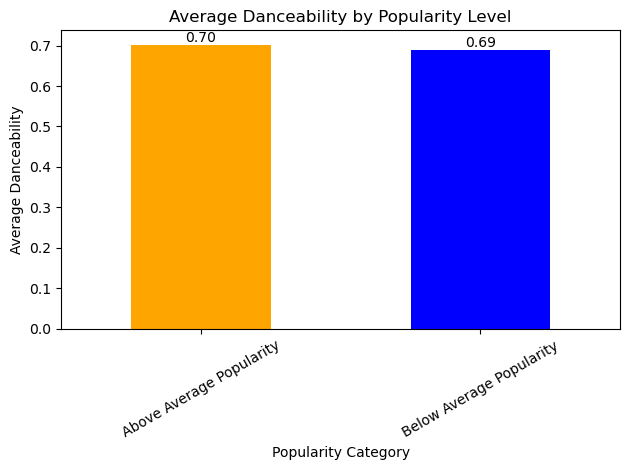

In [11]:
rq4_danceability_df = rq4_danceability_df.sort_values("POPULARITY_CATEGORY")
rq4_1 = rq4_danceability_df.plot(
  x="POPULARITY_CATEGORY",
  y="AVG_DANCEABILITY", 
  kind="bar",
  color=["orange", "blue"],
  legend=False
)

for container in rq4_1.containers:
    rq4_1.bar_label(container, fmt="%.2f")

plt.title("Average Danceability by Popularity Level")
plt.xticks(rotation=30)
plt.xlabel("Popularity Category")
plt.ylabel("Average Danceability")
plt.tight_layout()
plt.show()

In [12]:
#### Speechiness Visualization

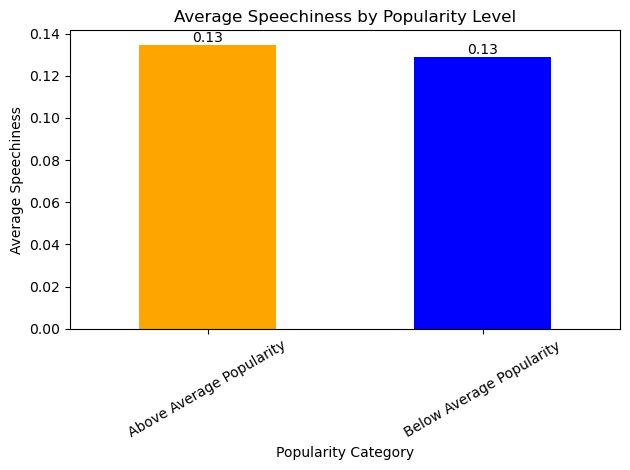

In [13]:
rq4_speechiness_df = rq4_speechiness_df.sort_values("POPULARITY_CATEGORY")
rq4_2 = rq4_speechiness_df.plot(
  x="POPULARITY_CATEGORY",
  y="AVG_SPEECHINESS", 
  kind="bar",
  color=["orange", "blue"],
  legend=False
)

for container in rq4_2.containers:
    rq4_2.bar_label(container, fmt="%.2f")

plt.title("Average Speechiness by Popularity Level")
plt.xticks(rotation=30)
plt.xlabel("Popularity Category")
plt.ylabel("Average Speechiness")
plt.tight_layout()
plt.show()

In [14]:
cur.close()
connection.close()